In [2]:
# Setup
import importlib
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz
import numpy as np

import sccoda.datasets as scd

from sccoda.model.scCODA_model import EricaModel

In [3]:
def values(arr):
        mean = arr.mean(axis=(0,1))               
        lo = np.percentile(arr, 2.5, axis=(0,1))  
        hi = np.percentile(arr, 97.5, axis=(0,1))  
        return mean, lo, hi

In [4]:
def summarize(data, prior_label, reference=0):
    "Extract summaries from inference data object"
    
    pred = data.posterior_predictive["prediction"].values
    cell_types = list(data.posterior_predictive.cell_type.values)
    reference_name = cell_types[reference]
    
    # Overall expected samples
    pred_mean, pred_lo, pred_hi = values(pred)            
    pred_mean = pred_mean.mean(axis=0)                   
    pred_lo   = pred_lo.mean(axis=0)
    pred_hi   = pred_hi.mean(axis=0)
    
     # intercept expected sample
    alpha = data.posterior["alpha"].values  
    alpha_mean, alpha_lo, alpha_hi = values(alpha)  
    
     # effect expected sample
    beta = data.posterior["beta"].values[..., 0, :]
    beta_mean, beta_lo, beta_hi = values(beta)
    
    #log fold change
    ref_pred = pred[..., reference:reference+1]
    logfc = np.log2(pred / ref_pred)                    
    logfc_mean, logfc_lo, logfc_hi = values(logfc)       
    logfc_mean = logfc_mean.mean(axis=0)           
    logfc_lo   = logfc_lo.mean(axis=0)
    logfc_hi   = logfc_hi.mean(axis=0)
    
    rows = []
    for i, ct in enumerate(cell_types):
        rows.append({
            "cell_type": ct, "reference": reference_name, "prior": prior_label,
            "metric": "expected_sample",
            "mean": pred_mean[i], "lo": pred_lo[i], "hi": pred_hi[i]
        })
        rows.append({
            "cell_type": ct, "reference": reference_name, "prior": prior_label,
            "metric": "intercept_expected_sample",
            "mean": alpha_mean[i], "lo": alpha_lo[i], "hi": alpha_hi[i]
        })
        rows.append({
            "cell_type": ct, "reference": reference_name, "prior": prior_label,
            "metric": "effect_expected_sample",
            "mean": beta_mean[i], "lo": beta_lo[i], "hi": beta_hi[i]
        })
        rows.append({
            "cell_type": ct, "reference": reference_name, "prior": prior_label,
            "metric": "log2FC",
            "mean": logfc_mean[i], "lo": logfc_lo[i], "hi": logfc_hi[i]
        })

    return pd.DataFrame(rows)

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_grid(df, param_name=None):
    metrics = ["expected_sample", "log2FC", "effect_expected_sample", "intercept_expected_sample"]
    titles  = ["Expected Samples", "Log2 Fold Change", "Effect Expected Sample", "Intercept Expected Sample"]

    n_metrics = len(metrics)
    cell_types = df["cell_type"].unique()
    n_cells = len(cell_types)

    prior_order = ["low", "default", "high"]

    palette = {
        "expected_sample": "#4C72B0",         
        "log2FC": "#55A868",                   
        "effect_expected_sample": "#C44E52",   
        "intercept_expected_sample": "#8172B2" 
    }

    fig, axes = plt.subplots(n_cells, n_metrics, figsize=(4*n_metrics, 3*n_cells), sharex=False)

    if n_cells == 1:
        axes = axes[np.newaxis, :]  

    for i, ct in enumerate(cell_types):
        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            sub = df[(df["cell_type"] == ct) & (df["metric"] == metric)].copy()

            # sort priors
            sub["prior"] = pd.Categorical(sub["prior"], categories=prior_order, ordered=True)
            sub = sub.sort_values("prior")

            color = palette[metric]

            if metric == "expected_sample":
                ax.bar(sub["prior"], sub["mean"], color=color, alpha=0.8)
            else:
                ax.plot(sub["prior"], sub["mean"], marker="o", color=color, linewidth=2)
                ax.fill_between(
                    sub["prior"], sub["lo"], sub["hi"],
                    color=color, alpha=0.2
                )

            ax.set_xticks(range(len(prior_order)))
            ax.set_xticklabels(prior_order, rotation=45, ha="right", fontsize=9)
            ax.tick_params(axis="y", labelsize=8)
            ax.grid(True, linestyle="--", alpha=0.4)

            if i == 0:
                ax.set_title(titles[j], fontsize=11, fontweight="bold")
            if j == 0:
                ax.set_ylabel(ct, fontsize=9, fontweight="bold")
            else:
                ax.set_ylabel("")

    if param_name is not None:
        fig.suptitle(f"{param_name}", fontsize=14, fontweight="bold", y=1.02)
        
    plt.tight_layout()
    return fig, axes

In [6]:
data = pd.read_csv("/users/ebrown62/scCODA/sccoda/datasets/scCODA_simulated_n=2.csv")
data = data.set_index("donor_id")
data.head()


,x_cont1,x_cont2,x_cont3,x_cont4,x_cont5,x_cont6,x_cont7,x_cont8,x_cont9,x_cont10,...,C(cat0)[3],C(cat1)[T.2],C(cat2)[T.3],x_bin1,x_bin2,CT1,CT2,CT3,CT4,CT5
donor_id,,,,,,,,,,,,,,,,,,,,,
S001,1.066880,0.194549,-0.530829,0.091901,-0.177537,-0.919309,-2.077756,2.039190,0.802900,-0.930904,...,0.0,1.0,0.0,1.0,2.0,1,0,0,163,9
S002,-0.372431,-0.320974,-2.761791,2.220130,-0.524029,2.044230,-1.503317,-0.920992,1.656566,1.216500,...,1.0,0.0,1.0,1.0,1.0,7,5,1,66,0


In [7]:
columns = data.columns.tolist()
cell_types = [col for col in columns if "CT" in col]

automatic_reference_absence_threshold = 0.05
percent_zero = np.sum(data[cell_types] == 0, axis=0)/data
nonrare_ct = np.where(percent_zero < automatic_reference_absence_threshold)[0]

row_totals = data[cell_types].sum(axis=1).replace(0, np.nan)
rel_abun = data[cell_types].div(row_totals, axis=0)

ra_vals = rel_abun.to_numpy()
cell_type_disp = np.var(ra_vals, axis=0) / np.mean(ra_vals, axis=0)

# select reference
min_var_idx_within = np.argmin(cell_type_disp[nonrare_ct])
ref_index = nonrare_ct[min_var_idx_within]


ref_cell_type = cell_types[ref_index]
print(f"Automatic reference selection! Reference cell type set to {ref_cell_type}")


Automatic reference selection! Reference cell type set to CT2


In [8]:
data.head()
data.columns

Index(['x_cont1', 'x_cont2', 'x_cont3', 'x_cont4', 'x_cont5', 'x_cont6',
       'x_cont7', 'x_cont8', 'x_cont9', 'x_cont10', 'C(cat0)[1]', 'C(cat0)[3]',
       'C(cat1)[T.2]', 'C(cat2)[T.3]', 'x_bin1', 'x_bin2', 'CT1', 'CT2', 'CT3',
       'CT4', 'CT5'],
      dtype='object')

In [9]:
data_matrix = data[cell_types].to_numpy()
covariates = [col for col in data.columns if col not in cell_types]
covariate_matrix = data[covariates].to_numpy()
covariate_names = covariates

In [10]:
data_matrix = data[cell_types].to_numpy()

simulation_model_n2 = EricaModel(
   reference_cell_type=ref_index,
   data_matrix=data_matrix,
   covariate_matrix=covariate_matrix,
   cell_types=cell_types,
   covariate_names=covariate_names,
   formula= "~ " + " + ".join(covariates)
)
simulation_basic_n2 = simulation_model_n2.sample_hmc(
   num_results=5000, 
   num_burnin=1000,
   step_size=0.01,
   num_leapfrog_steps=20
)
print(simulation_basic_n2.summary())

2025-10-24 12:16:17.935540: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Zero counts encountered in data! Added a pseudocount of 0.5.


2025-10-24 12:16:20.545663: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f03480077c0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-10-24 12:16:20.545683: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
  0%|                                                                                                                         | 0/5000 [00:00<?, ?it/s]2025-10-24 12:16:20.713605: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1761322581.768241  887170 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:34<00:00, 143.78it/s]


MCMC sampling finished. (44.069 sec)
Acceptance rate: 47.5%
Compositional Analysis summary:

Data: 2 samples, 5 cell types
Reference index: 1
Formula: ~ x_cont1 + x_cont2 + x_cont3 + x_cont4 + x_cont5 + x_cont6 + x_cont7 + x_cont8 + x_cont9 + x_cont10 + C(cat0)[1] + C(cat0)[3] + C(cat1)[T.2] + C(cat2)[T.3] + x_bin1 + x_bin2

Intercepts:
           Final Parameter  Expected Sample
Cell Type                                  
CT1                 -0.941         3.799128
CT2                  0.137        11.164863
CT3                 -1.685         1.805381
CT4                  2.410       108.393877
CT5                 -2.454         0.836751


Effects:
                     Final Parameter  Expected Sample  log2-fold change
Covariate Cell Type                                                    
x_cont1   CT1                    0.0         3.799128               0.0
          CT2                    0.0        11.164863               0.0
          CT3                    0.0         1.805381 

In [27]:
true_beta_csv = pd.read_csv("/users/ebrown62/scCODA/sccoda/datasets/scCODA_simulated_N=2_K=5_P=16_SEED=0_true_beta.csv")
b_raw_csv =  pd.read_csv("/users/ebrown62/scCODA/sccoda/datasets/results/n=unknown/alpha_loc/alpha_loc_braw.csv")
tau_csv = pd.read_csv("/users/ebrown62/scCODA/sccoda/datasets/results/n=unknown/alpha_loc/alpha_loc_tau.csv")

prior = "default"

b_raw_csv = b_raw_csv[b_raw_csv["prior"] == prior]
tau_csv = tau_csv[tau_csv["prior"] == prior]
mean_b_cols = [c for c in b_raw_csv.columns if "mean" in c]
b_raw_mean = b_raw_csv[mean_b_cols]
mean_tau_cols = [c for c in tau_csv.columns if "mean" in c]
tau_mean = tau_csv[mean_tau_cols]


In [ ]:
true_beta_csv = true_beta_csv.drop(columns=["CT5"])

,CT1,CT2,CT3,CT4
0,1.613990,2.449530,-1.153010,-0.334353
1,-0.488661,-1.349927,0.408762,-0.755513
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000


In [19]:
full_effect_size = b_raw_mean.values * tau_mean.values

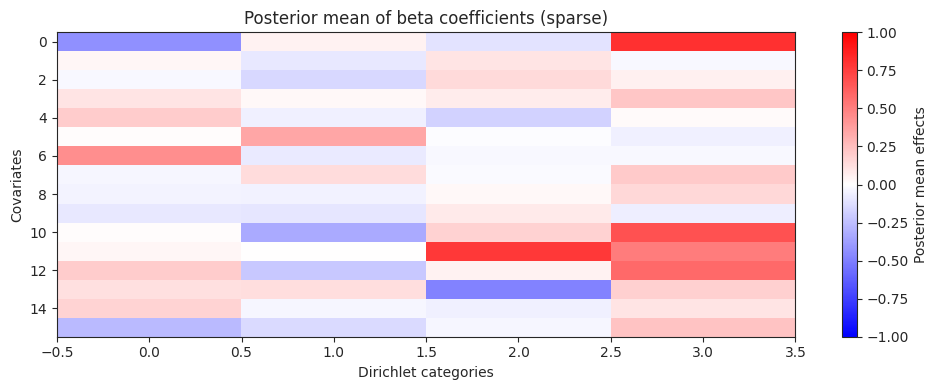

In [21]:
plt.figure(figsize=(10,4))
plt.imshow(full_effect_size, aspect="auto", cmap="bwr", vmin=-1, vmax=1)
plt.colorbar(label="Posterior mean effects")
plt.xlabel("Dirichlet categories")
plt.ylabel("Covariates")
plt.title("Posterior mean of beta coefficients (sparse)")
plt.tight_layout()
plt.show()

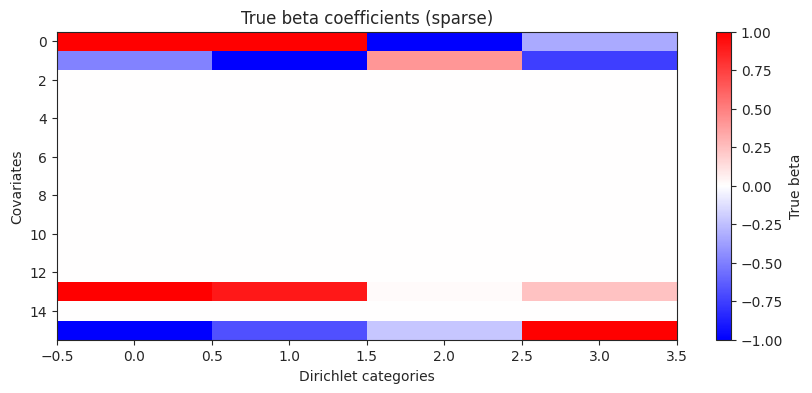

In [32]:
plt.figure(figsize=(10,4))
plt.imshow(true_beta_csv, aspect="auto", cmap="bwr", vmin=-1, vmax=1)
plt.colorbar(label="True beta")
plt.xlabel("Dirichlet categories")
plt.ylabel("Covariates")
plt.title("True beta coefficients (sparse)")
plt.show()

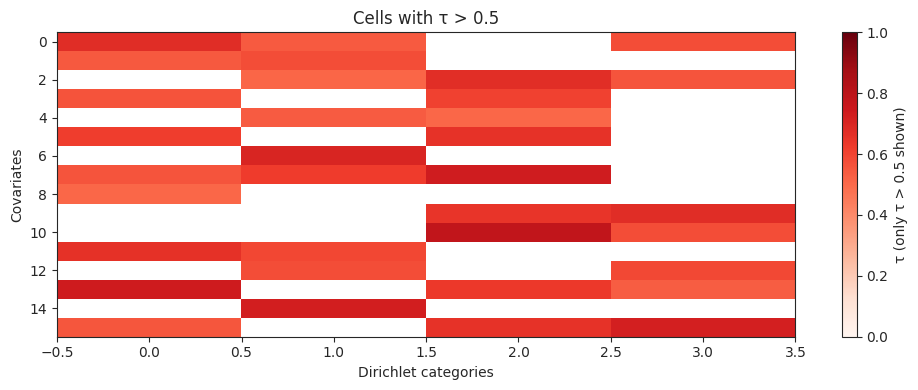

In [34]:
import numpy as np
threshold_csv = tau_mean.where(tau_mean > 0.5, np.nan)
plt.figure(figsize=(10, 4))
plt.imshow(threshold_csv.to_numpy(dtype=float),
           aspect="auto", cmap="Reds", vmin=0, vmax=1)
plt.colorbar(label="τ (only τ > 0.5 shown)")
plt.xlabel("Dirichlet categories")
plt.ylabel("Covariates")
plt.title("Cells with τ > 0.5")
plt.tight_layout()
plt.show()